### 한국어 혐오표현 데이터
- https://github.com/smilegate-ai/korean_unsmile_dataset
- 10가지를 분류하는 모델을 직접 만들어보자
- 전처리, 순환신경망, 임베딩 등을 직접 적용해보는 실습

In [1]:
# 작업디렉토리 변경
#%pwd "/content/drive/My drvie/AI"
%cd "/content/drive/MyDrive/AI/인사교_자연어처리"

/content/drive/MyDrive/AI/인사교_자연어처리


In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
train_text = pd.read_csv("./unsmile_train_v1.0.tsv",
                          delimiter="\t")
test_text = pd.read_csv("./unsmile_valid_v1.0.tsv",
                         delimiter="\t")
train_text.shape, test_text.shape

((15005, 12), (3737, 12))

In [7]:
import pandas as pd
# 멀티레이블 확인하기
train_text ['multi_label'] = train_text.iloc[:,1:11].sum(axis=1)
train_text[train_text['multi_label'] > 1]

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,multi_label
6,예수 십새끼 개새끼 창녀아들 애비실종 가정교육 못받은 무뇌충 허언증 정신병자 사기꾼...,0,0,0,1,0,1,1,1,0,0,0,4
11,이슬람뺨치내,0,0,0,1,0,0,1,0,0,0,0,2
13,갓슬람 정희구현 테러 ㅅㅅㅅㅅ미제양키새끼들에게는 테러가 답이다좆같은 양키 씨발새끼들,0,0,0,1,0,0,1,0,0,0,0,2
48,할카스가 머임?상폐보지중 부패한보지임?,1,0,0,0,1,0,0,0,0,0,0,2
61,로봉순 젠신병자니까 맘껏패라 사람아님,0,0,1,0,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14923,가게에서 카운터 보고 있는데 내 또래 미국새끼 왔길래 가격 영어로 말해 줬더니 중1...,0,0,1,1,0,0,0,0,0,0,0,2
14924,저 병신년들은 남자들이 그렇게 방관하고 동조한걸 알고있으면서도 지들도 같이하네ㅋㅋㅋ...,1,0,1,0,0,0,0,0,0,0,0,2
14926,개독 vs 홍어 vs 개슬람종족 밸런스 쩌네,0,0,0,0,0,1,1,0,0,0,0,2
14955,30~40대 김치년이 많이 있어서 그런거지,1,0,0,0,1,0,0,0,0,0,0,2


In [14]:
train_df = pd.read_csv('./unsmile_valid_v1.0.tsv', delimiter='\t')
test_df = pd.read_csv('./unsmile_valid_v1.0.tsv', delimiter='\t')
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

In [9]:
from numpy import index_exp
# 멀티레이블 제거하기
multi_label_index = train_text[train_text['multi_label']>1].index
train_text.drop(multi_label_index, inplace=True)

In [10]:
train_text.shape

(14011, 13)

In [19]:
from datasets import load_dataset
datasets = load_dataset('smilegate-ai/kor_unsmile')
print(datasets)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/290k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15005 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/3737 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭', 'labels'],
        num_rows: 15005
    })
    valid: Dataset({
        features: ['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭', 'labels'],
        num_rows: 3737
    })
})


In [20]:
train_df_from_datasets = datasets['train'].to_pandas()
display(train_df_from_datasets.head())

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,labels
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,0,0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]"
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,1,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]"
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,0,0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


In [22]:
from transformers import TextClassificationPipeline, BertForSequenceClassification, AutoTokenizer
model_name = 'smilegate-ai/kor_unsmile'
model = BertForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
pipe = TextClassificationPipeline(
        model = model,
        tokenizer = tokenizer,
        device = 0,   # cpu: -1, gpu: gpu number
        return_all_scores = True,
        function_to_apply = 'sigmoid'
    )
for result in pipe("이래서 여자는 게임을 하면 안된다")[0]:
        print(result)

{'label': '여성/가족', 'score': 0.8253053426742554}
{'label': '남성', 'score': 0.039725180715322495}
{'label': '성소수자', 'score': 0.012144332751631737}
{'label': '인종/국적', 'score': 0.023181889206171036}
{'label': '연령', 'score': 0.010315303690731525}
{'label': '지역', 'score': 0.018454890698194504}
{'label': '종교', 'score': 0.011270025745034218}
{'label': '기타 혐오', 'score': 0.0207340307533741}
{'label': '악플/욕설', 'score': 0.057331427931785583}
{'label': 'clean', 'score': 0.1401052623987198}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

label
score


{'label': 'clean', 'score': 0.1401052623987198}

In [23]:
from tensorflow.keras.models import Sequential  # 모델의 뼈대
from tensorflow.keras.layers import InputLayer  # 입력층
from tensorflow.keras.layers import Dense       # 뉴런의 묶음
from tensorflow.keras.layers import SimpleRNN   # 바닐라 RNN 구현체

In [24]:
# 뼈대생성
model = Sequential()
# 입력층
model.add(InputLayer(shape=(10, 1)))                # 시퀸스의 길이, 입력 특성 수
# 중간층
model.add(SimpleRNN(units=64))                      # 순환신경망 레이어 추가, 활성화 함수 생략가능
# 출력층
model.add(Dense(units=1, activation='sigmoid'))     # 이진분류(긍정/부정)

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    loss = "binary_crossentropy",   # 모델의 손실값 (틀린정도)을 파악하는 도구
    optimizer = "adam",             # 손실값을 기반으로 방향을 알려주는 도구(최적화)
    metrics = ["accuracy"]          # 정확도 평가지표 추가
)

In [39]:
simple_his = model.fit(
    X_train_vec,                # 학습용 문제
    train_df['label'],          # 학습용 정답
    epochs = 40,                # 학습횟수
    batch_size = 128,           # 학습시 한 번에 사용하는 샘플수
    validation_split = 0.2      # 검증데이터 분할
)

KeyError: 'label'

In [31]:
import matplotlib.pyplot as plt

In [36]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. 토크나이저 설정 (데이터셋의 문장 개수에 따라 조정 가능)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df['문장']) # 혹은 사용 중인 데이터프레임의 텍스트 컬럼명

# 2. 텍스트를 정수 시퀀스로 변환
sequences = tokenizer.texts_to_sequences(train_df['문장'])

# 3. 패딩 처리 (모델의 InputLayer shape에 맞춰 길이를 10으로 설정)
X_train_vec = pad_sequences(sequences, maxlen=10)

In [41]:
# 1. 정답 데이터 추출
# 현재 데이터셋(train_df)의 정답 컬럼명이 무엇인지 확인이 필요합니다.
# 만약 'clean' 컬럼을 정답으로 쓴다면 아래와 같이 작성합니다.
y_train = train_df['clean'].values

# 또는, 만약 여러 라벨을 한꺼번에 사용한다면:
# y_train = train_df.iloc[:, 1:11].values

In [42]:
# 선행되어야 할 학습 코드
simple_his = model.fit(
    X_train_vec,        # 학습 데이터
    y_train,            # 정답 데이터 (train_df['label'] 등)
    epochs=40,          # 학습 횟수
    batch_size=128,     # 배치 사이즈
    validation_split=0.2 # 검증 데이터 비율
)

Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6828 - loss: 0.6133 - val_accuracy: 0.7513 - val_loss: 0.5611
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7494 - loss: 0.5616 - val_accuracy: 0.7527 - val_loss: 0.5598
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7494 - loss: 0.5608 - val_accuracy: 0.7527 - val_loss: 0.5618
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7494 - loss: 0.5615 - val_accuracy: 0.7527 - val_loss: 0.5595
Epoch 5/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7494 - loss: 0.5606 - val_accuracy: 0.7527 - val_loss: 0.5609
Epoch 6/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7494 - loss: 0.5608 - val_accuracy: 0.7527 - val_loss: 0.5595
Epoch 7/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7494 - loss: 0.5606 - val_accuracy: 0.7527 - val_loss: 0.5603
Epoch 8/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7494 - loss: 0.5613 - val_accuracy: 0.7527 - val_loss

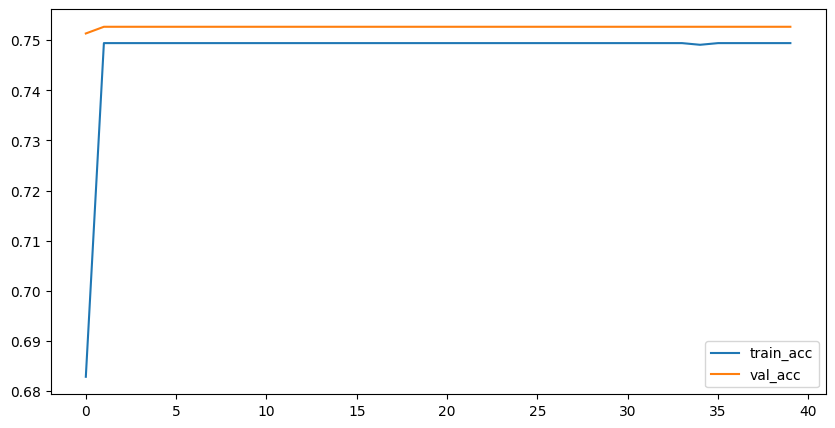

In [43]:
plt.figure(figsize=(10, 5))  # 가로, 세로 사이즈
plt.plot(simple_his.history['accuracy'], label='train_acc')
plt.plot(simple_his.history['val_accuracy'], label='val_acc')
plt.legend() # 범례
plt.show()